# Aprendizado de Máquina — seções 1, 2 e 3
### GCC1734 Inteligência Artificial · CEFET/RJ

Este notebook acompanha as seções iniciais das notas de aula 07:

- **Seção 1:** motivação, hipótese de aprendizagem, relação com outros paradigmas e taxonomia.
- **Seção 2:** framework de aprendizado supervisionado: dados, hipóteses, perdas, generalização e divisão treino/validação/teste.
- **Seção 3:** modelos lineares: regressão linear, gradiente descendente, regressão logística e engenharia de características.

Os exemplos usam dados sintéticos pequenos para que cada célula seja inspecionável em sala.


In [1]:
# Configuração global
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.datasets import make_classification, make_moons
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    log_loss,
    mean_absolute_error,
    mean_squared_error,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

RNG = np.random.default_rng(42)
np.set_printoptions(precision=3, suppress=True)


---
## 1. Motivação e contexto

A pergunta prática de aprendizado de máquina é: **dado um conjunto de dados sobre um fenômeno, que regularidades podem ser extraídas para tomar decisões em casos novos?**

A primeira célula não treina modelos; ela organiza os paradigmas que aparecem nas notas e ajuda a separar o tipo de sinal disponível em cada caso.


In [2]:
paradigmas = pd.DataFrame(
    [
        ("Busca", "modelo completo", "nenhum", "plano ou caminho"),
        ("Minimax", "modelo adversarial", "utilidade", "ação em jogo adversarial"),
        ("MCTS", "simulador/regras", "resultados de simulações", "estimativas de ações"),
        ("Aprendizado por reforço", "sem modelo", "recompensa", "política de ação"),
        ("AM supervisionado", "exemplos rotulados", "rótulo y", "função entrada-saída"),
        ("AM não supervisionado", "entradas sem rótulo", "nenhum rótulo", "estrutura nos dados"),
    ],
    columns=["Paradigma", "Conhecimento fornecido", "Sinal de aprendizado", "Objeto produzido"],
)
paradigmas


,Paradigma,Conhecimento fornecido,Sinal de aprendizado,Objeto produzido
0,Busca,modelo completo,nenhum,plano ou caminho
1,Minimax,modelo adversarial,utilidade,ação em jogo adversarial
2,MCTS,simulador/regras,resultados de simulações,estimativas de ações
3,Aprendizado por reforço,sem modelo,recompensa,política de ação
4,AM supervisionado,exemplos rotulados,rótulo y,função entrada-saída
5,AM não supervisionado,entradas sem rótulo,nenhum rótulo,estrutura nos dados


### Hipótese de aprendizagem em código

O exemplo abaixo mostra a suposição central das notas: o conjunto de treino e os casos futuros devem vir de processos suficientemente semelhantes.

Treinamos uma regressão linear em um período histórico em que `y ≈ 2x + 1`. Depois avaliamos em dois cenários:

- futuro semelhante: mesma regularidade;
- futuro com mudança de distribuição: a relação entre `x` e `y` mudou.


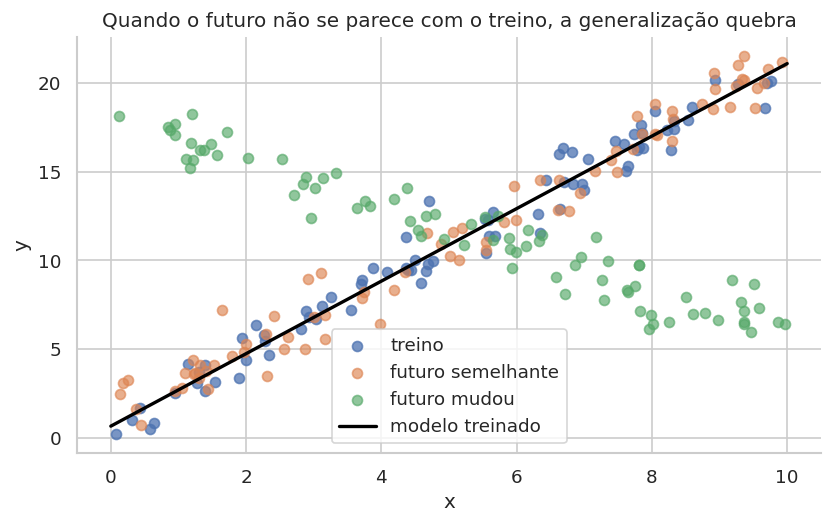

,Cenário,RMSE
0,treino,0.924196
1,futuro semelhante,1.072989
2,futuro com mudança,9.326099


In [3]:
n = 80
x_train = RNG.uniform(0, 10, size=n)
y_train = 2 * x_train + 1 + RNG.normal(0, 1.0, size=n)

x_future_ok = RNG.uniform(0, 10, size=n)
y_future_ok = 2 * x_future_ok + 1 + RNG.normal(0, 1.0, size=n)

x_future_shift = RNG.uniform(0, 10, size=n)
y_future_shift = -1.2 * x_future_shift + 18 + RNG.normal(0, 1.0, size=n)

modelo = LinearRegression().fit(x_train.reshape(-1, 1), y_train)

def rmse(y, pred):
    return mean_squared_error(y, pred) ** 0.5

resultados_shift = pd.DataFrame(
    {
        "Cenário": ["treino", "futuro semelhante", "futuro com mudança"],
        "RMSE": [
            rmse(y_train, modelo.predict(x_train.reshape(-1, 1))),
            rmse(y_future_ok, modelo.predict(x_future_ok.reshape(-1, 1))),
            rmse(y_future_shift, modelo.predict(x_future_shift.reshape(-1, 1))),
        ],
    }
)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(x_train, y_train, label="treino", alpha=0.75)
ax.scatter(x_future_ok, y_future_ok, label="futuro semelhante", alpha=0.65)
ax.scatter(x_future_shift, y_future_shift, label="futuro mudou", alpha=0.65)
xs = np.linspace(0, 10, 100)
ax.plot(xs, modelo.predict(xs.reshape(-1, 1)), color="black", lw=2, label="modelo treinado")
ax.set(xlabel="x", ylabel="y", title="Quando o futuro não se parece com o treino, a generalização quebra")
ax.legend()
plt.show()

resultados_shift


---
## 2. Framework de aprendizado supervisionado

No aprendizado supervisionado trabalhamos com pares:

$$
D = \{(x^{(1)}, y^{(1)}), \ldots, (x^{(n)}, y^{(n)})\}
$$

O vetor `x` contém características e `y` é o alvo. O algoritmo escolhe uma hipótese `h` dentro de um espaço de hipóteses `H` e ajusta parâmetros para reduzir uma função de perda.


In [4]:
# Um mini-problema de spam sintético, inspirado no exemplo das notas.
email = pd.DataFrame(
    {
        "freq_gratis": [0, 1, 3, 0, 2, 5, 0, 1, 4, 0, 3, 1],
        "num_links": [0, 1, 4, 0, 3, 6, 1, 0, 5, 0, 4, 1],
        "tam_assunto": [18, 42, 65, 21, 50, 80, 28, 35, 70, 16, 60, 38],
        "dominio_conhecido": [1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1],
        "spam": [0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0],
    }
)

X = email.drop(columns="spam")
y = email["spam"]

display(email)
print(f"n = {len(email)} exemplos, d = {X.shape[1]} características")


,freq_gratis,num_links,tam_assunto,dominio_conhecido,spam
0,0,0,18,1,0
1,1,1,42,1,0
2,3,4,65,0,1
3,0,0,21,1,0
4,2,3,50,0,1
5,5,6,80,0,1
6,0,1,28,1,0
7,1,0,35,1,0
8,4,5,70,0,1
9,0,0,16,1,0


n = 12 exemplos, d = 4 características


### Funções de perda

A perda transforma "errar pouco" em número. A célula seguinte compara quatro perdas comuns das notas em previsões inventadas para regressão e classificação.


In [5]:
# Regressão: duas previsões para os mesmos alvos.
y_real_reg = np.array([10, 12, 14, 16])
y_pred_boa = np.array([10.5, 11.5, 14.2, 15.7])
y_pred_ruim = np.array([7, 10, 20, 17])

# Classificação binária: rótulos e probabilidades previstas para y=1.
y_real_cls = np.array([0, 0, 1, 1])
p_boa = np.array([0.05, 0.20, 0.80, 0.95])
p_ruim = np.array([0.90, 0.70, 0.40, 0.10])

perdas = pd.DataFrame(
    [
        ("MSE", "regressão", mean_squared_error(y_real_reg, y_pred_boa), mean_squared_error(y_real_reg, y_pred_ruim)),
        ("MAE", "regressão", mean_absolute_error(y_real_reg, y_pred_boa), mean_absolute_error(y_real_reg, y_pred_ruim)),
        ("0-1", "classificação", 1 - accuracy_score(y_real_cls, p_boa >= 0.5), 1 - accuracy_score(y_real_cls, p_ruim >= 0.5)),
        ("Entropia cruzada", "classificação", log_loss(y_real_cls, p_boa), log_loss(y_real_cls, p_ruim)),
    ],
    columns=["Perda", "Tarefa", "previsão boa", "previsão ruim"],
)
perdas


,Perda,Tarefa,previsão boa,previsão ruim
0,MSE,regressão,0.157500,12.500000
1,MAE,regressão,0.375000,3.000000
2,0-1,classificação,0.000000,1.000000
3,Entropia cruzada,classificação,0.137218,1.681358


### Divisão treino, validação e teste

O conjunto de treino ajusta parâmetros. A validação orienta escolhas de projeto, como complexidade do modelo. O teste fica isolado para a avaliação final.

Aqui usamos um conjunto sintético maior para mostrar o fluxo completo.


In [6]:
X_all, y_all = make_classification(
    n_samples=600,
    n_features=4,
    n_informative=3,
    n_redundant=0,
    class_sep=1.0,
    flip_y=0.08,
    random_state=42,
)

X_temp, X_test, y_temp, y_test = train_test_split(
    X_all, y_all, test_size=0.20, stratify=y_all, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42
)

divisao = pd.DataFrame(
    {
        "parte": ["treino", "validação", "teste"],
        "exemplos": [len(y_train), len(y_val), len(y_test)],
        "proporção de spam/classe 1": [y_train.mean(), y_val.mean(), y_test.mean()],
    }
)
divisao


,parte,exemplos,proporção de spam/classe 1
0,treino,360,0.511111
1,validação,120,0.516667
2,teste,120,0.516667


In [7]:
# A validação escolhe um hiperparâmetro: C controla a regularização da regressão logística.
linhas = []
modelos = {}

for C in [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100, 300]:
    clf = make_pipeline(StandardScaler(), LogisticRegression(C=C, max_iter=1000, random_state=42))
    clf.fit(X_train, y_train)
    modelos[C] = clf
    linhas.append(
        {
            "C": C,
            "acurácia treino": accuracy_score(y_train, clf.predict(X_train)),
            "acurácia validação": accuracy_score(y_val, clf.predict(X_val)),
        }
    )

comparacao = pd.DataFrame(linhas)
melhor_C = comparacao.loc[comparacao["acurácia validação"].idxmax(), "C"]
modelo_escolhido = modelos[melhor_C]
acuracia_teste = accuracy_score(y_test, modelo_escolhido.predict(X_test))

display(comparacao)
print(f"C escolhido pela validação: {melhor_C}")
print(f"Acurácia no teste, consultada só ao final: {acuracia_teste:.3f}")


,C,acurácia treino,acurácia validação
0,0.001,0.816667,0.833333
1,0.003,0.841667,0.875000
2,0.010,0.847222,0.883333
3,0.030,0.850000,0.883333
4,0.100,0.847222,0.875000
5,0.300,0.847222,0.875000
6,1.000,0.844444,0.875000
7,3.000,0.844444,0.875000
8,10.000,0.847222,0.875000
9,30.000,0.844444,0.875000


C escolhido pela validação: 0.01
Acurácia no teste, consultada só ao final: 0.850


---
## 3. Modelos lineares

Um modelo linear combina características por soma ponderada:

$$
h_{w,b}(x) = w_1 x_1 + \cdots + w_d x_d + b
$$

Adicionando uma característica constante `x0 = 1`, o viés `b` pode ser absorvido no vetor de pesos.


### 3.1 Regressão linear: exemplo das notas

Dados:

| área (m²) | preço (R$ mil) |
|---:|---:|
| 50 | 200 |
| 100 | 350 |
| 150 | 500 |

A reta `h(x)=50+3x` ajusta perfeitamente os exemplos.


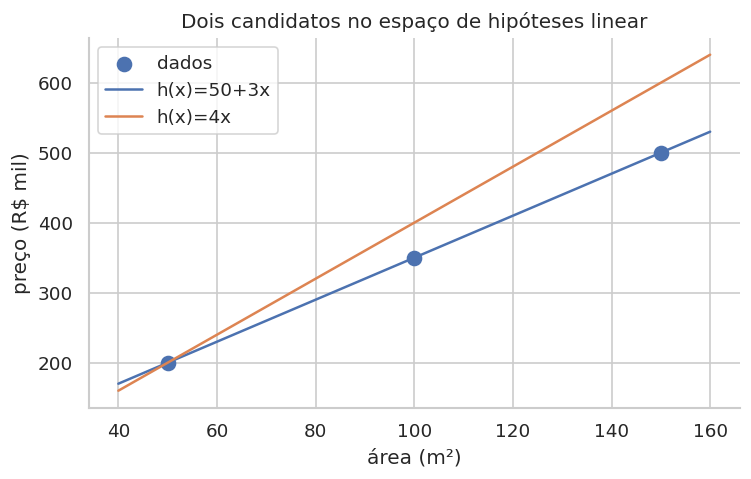

,b,w1,MSE
0,50,3,0.000000
1,0,4,4166.666667


In [9]:
area = np.array([50, 100, 150], dtype=float)
preco = np.array([200, 350, 500], dtype=float)

def pred_linear(x, b, w1):
    return b + w1 * x

def mse_manual(y_true, y_pred):
    return np.mean((y_pred - y_true) ** 2)

candidatos = pd.DataFrame(
    [
        {"b": 50, "w1": 3, "MSE": mse_manual(preco, pred_linear(area, 50, 3))},
        {"b": 0, "w1": 4, "MSE": mse_manual(preco, pred_linear(area, 0, 4))},
    ]
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(area, preco, s=70, label="dados")
xs = np.linspace(40, 160, 100)
ax.plot(xs, pred_linear(xs, 50, 3), label="h(x)=50+3x")
ax.plot(xs, pred_linear(xs, 0, 4), label="h(x)=4x")
ax.set(xlabel="área (m²)", ylabel="preço (R$ mil)", title="Dois candidatos no espaço de hipóteses linear")
ax.legend()
plt.show()

candidatos


In [10]:
# Equação normal: w* = (X^T X)^(-1) X^T y
X_design = np.column_stack([np.ones_like(area), area])
w_normal = np.linalg.inv(X_design.T @ X_design) @ X_design.T @ preco

pd.Series(w_normal, index=["b", "w1"], name="pesos pela equação normal")


b     50.0
w1     3.0
Name: pesos pela equação normal, dtype: float64

### 3.2 Gradiente descendente: um passo manual

Reproduzimos o passo das notas a partir de `b=0`, `w1=4` e `α=0.0001`.


In [11]:
b = 0.0
w1 = 4.0
alpha = 0.0001
n = len(area)

y_hat = pred_linear(area, b, w1)
erros = y_hat - preco
grad_b = (2 / n) * np.sum(erros)
grad_w1 = (2 / n) * np.sum(erros * area)

b_novo = b - alpha * grad_b
w1_novo = w1 - alpha * grad_w1

pd.DataFrame(
    {
        "grandeza": ["grad_b", "grad_w1", "b após atualização", "w1 após atualização"],
        "valor": [grad_b, grad_w1, b_novo, w1_novo],
    }
)


,grandeza,valor
0,grad_b,100.000000
1,grad_w1,13333.333333
2,b após atualização,-0.010000
3,w1 após atualização,2.666667


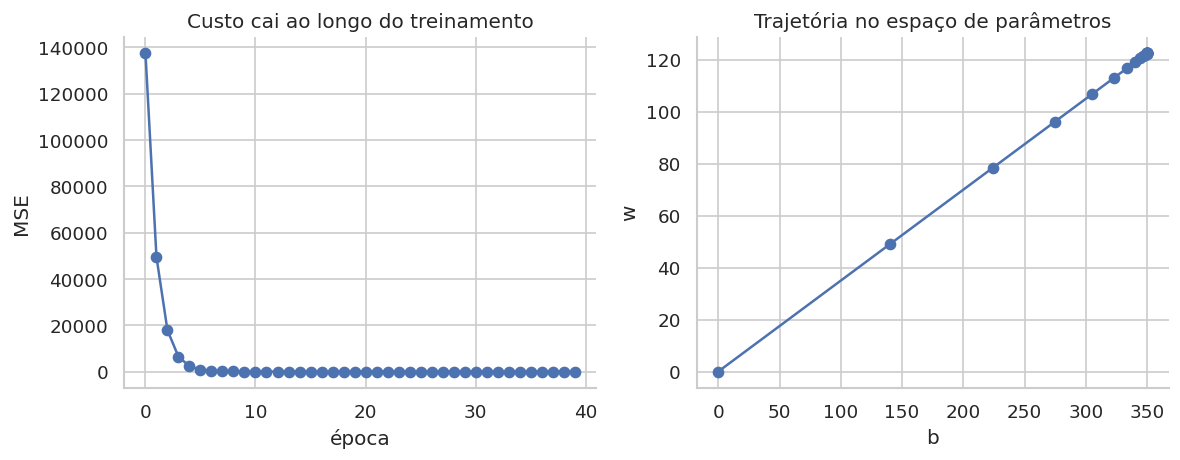

,época,b,w,MSE
35,35,349.999994,122.474485,4.063406e-11
36,36,349.999996,122.474486,1.462826e-11
37,37,349.999998,122.474486,5.266174e-12
38,38,349.999999,122.474487,1.895823e-12
39,39,349.999999,122.474487,6.824962e-13


In [12]:
# Várias iterações de gradiente descendente, com a área padronizada para estabilidade.
x = area
x_mean = x.mean()
x_std = x.std()
x_scaled = (x - x_mean) / x_std

b = 0.0
w = 0.0
alpha = 0.2
historico = []

for epoca in range(40):
    y_hat = b + w * x_scaled
    erro = y_hat - preco
    custo = np.mean(erro**2)
    historico.append({"época": epoca, "b": b, "w": w, "MSE": custo})
    b -= alpha * 2 * erro.mean()
    w -= alpha * 2 * np.mean(erro * x_scaled)

hist = pd.DataFrame(historico)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(hist["época"], hist["MSE"], marker="o")
axes[0].set(xlabel="época", ylabel="MSE", title="Custo cai ao longo do treinamento")

axes[1].plot(hist["b"], hist["w"], marker="o")
axes[1].set(xlabel="b", ylabel="w", title="Trajetória no espaço de parâmetros")
plt.tight_layout()
plt.show()

hist.tail()


### Por que padronizar características?

O gradiente descendente é sensível à escala. A célula abaixo compara a mesma taxa de aprendizado com e sem padronização.


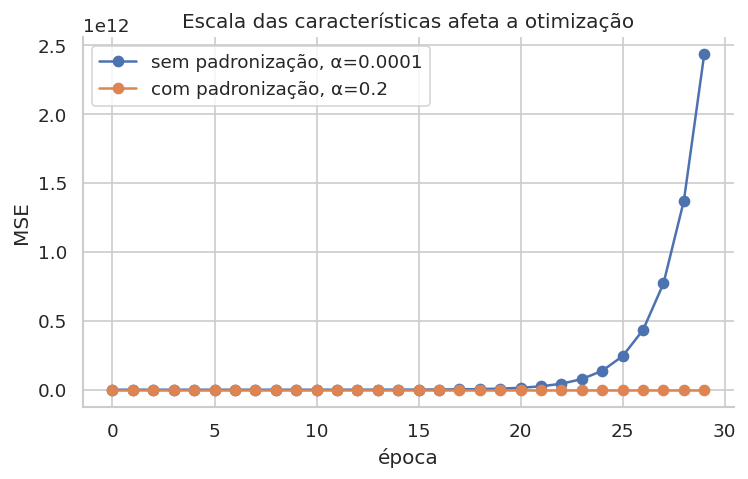

In [13]:
def gd_linear_1d(x, y, alpha, epocas):
    b = 0.0
    w = 0.0
    custos = []
    for _ in range(epocas):
        pred = b + w * x
        erro = pred - y
        custos.append(np.mean(erro**2))
        b -= alpha * 2 * erro.mean()
        w -= alpha * 2 * np.mean(erro * x)
    return np.array(custos)

custos_sem_escala = gd_linear_1d(area, preco, alpha=0.0001, epocas=30)
custos_com_escala = gd_linear_1d(x_scaled, preco, alpha=0.2, epocas=30)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(custos_sem_escala, marker="o", label="sem padronização, α=0.0001")
ax.plot(custos_com_escala, marker="o", label="com padronização, α=0.2")
ax.set(xlabel="época", ylabel="MSE", title="Escala das características afeta a otimização")
ax.legend()
plt.show()


### 3.3 Regressão logística e classificação binária

A regressão logística aplica a sigmoide à saída linear:

$$
\sigma(z)=\frac{1}{1+e^{-z}}
$$

O resultado é interpretado como uma probabilidade para a classe positiva.


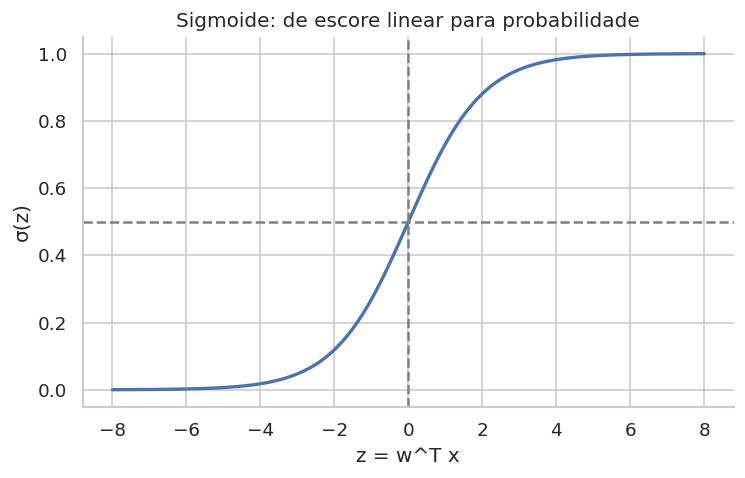

In [14]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-8, 8, 300)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(z, sigmoid(z), lw=2)
ax.axhline(0.5, color="gray", linestyle="--")
ax.axvline(0, color="gray", linestyle="--")
ax.set(xlabel="z = w^T x", ylabel="σ(z)", title="Sigmoide: de escore linear para probabilidade")
plt.show()


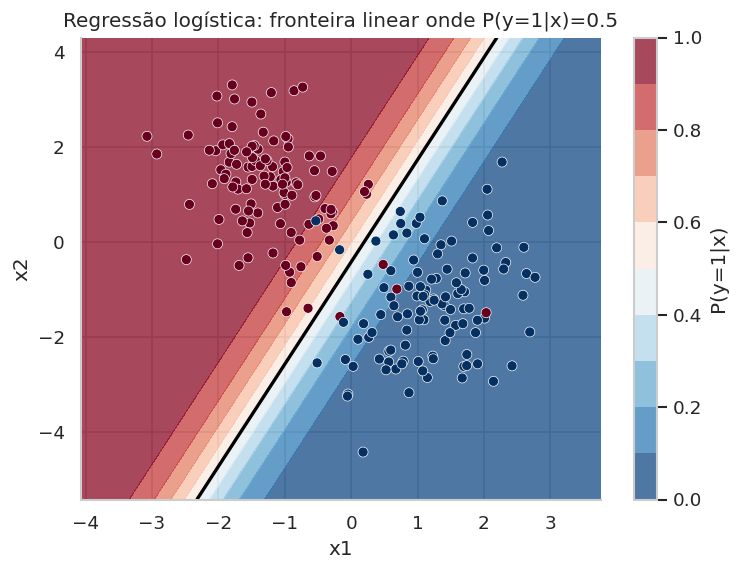

Acurácia no próprio conjunto sintético: 0.973


In [15]:
# Classificação binária com duas características para visualização.
X2, y2 = make_classification(
    n_samples=220,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=1.25,
    random_state=7,
)

logreg = make_pipeline(StandardScaler(), LogisticRegression(random_state=42))
logreg.fit(X2, y2)

xx, yy = np.meshgrid(
    np.linspace(X2[:, 0].min() - 1, X2[:, 0].max() + 1, 200),
    np.linspace(X2[:, 1].min() - 1, X2[:, 1].max() + 1, 200),
)
grid = np.c_[xx.ravel(), yy.ravel()]
prob = logreg.predict_proba(grid)[:, 1].reshape(xx.shape)

fig, ax = plt.subplots(figsize=(7, 5))
cont = ax.contourf(xx, yy, prob, levels=np.linspace(0, 1, 11), cmap="RdBu_r", alpha=0.75)
ax.contour(xx, yy, prob, levels=[0.5], colors="black", linewidths=2)
ax.scatter(X2[:, 0], X2[:, 1], c=y2, cmap="RdBu_r", edgecolor="white", linewidth=0.4)
fig.colorbar(cont, ax=ax, label="P(y=1|x)")
ax.set(title="Regressão logística: fronteira linear onde P(y=1|x)=0.5", xlabel="x1", ylabel="x2")
plt.show()

print(f"Acurácia no próprio conjunto sintético: {accuracy_score(y2, logreg.predict(X2)):.3f}")


### 3.4 Engenharia de características

Um modelo linear no espaço original só cria uma fronteira linear. Transformar características pode tornar um padrão não linear mais simples para o modelo.

Abaixo, o conjunto `make_moons` não é bem separado por uma reta. Acrescentar características polinomiais permite que a regressão logística produza uma fronteira curva.


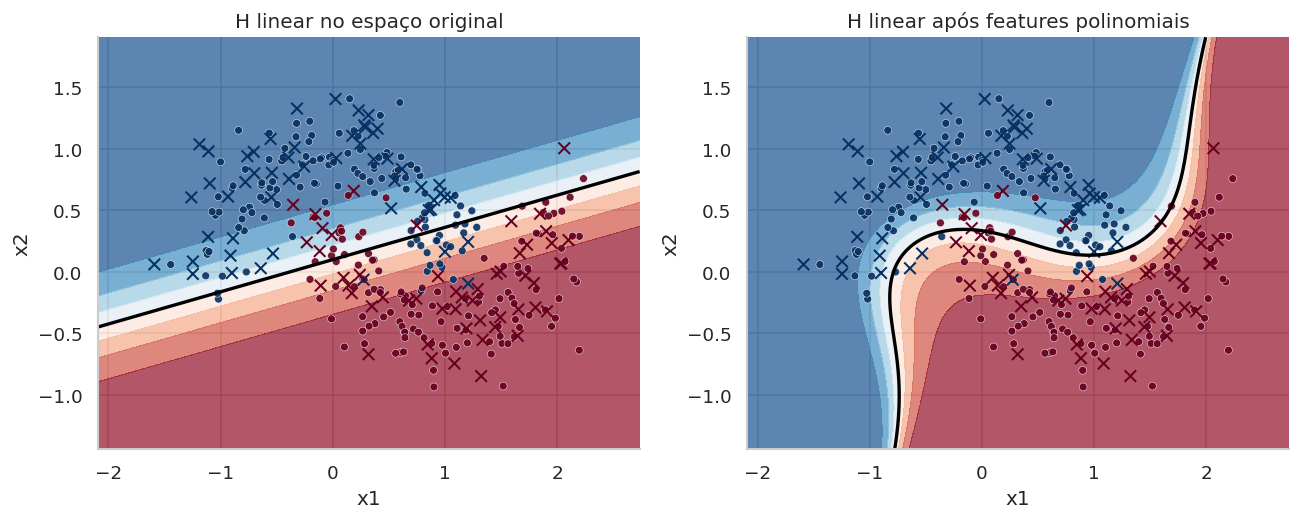

,modelo,acurácia treino,acurácia teste
0,logística linear,0.840816,0.876190
1,logística + features polinomiais grau 3,0.930612,0.904762


In [16]:
Xm, ym = make_moons(n_samples=350, noise=0.22, random_state=42)
Xm_train, Xm_test, ym_train, ym_test = train_test_split(
    Xm, ym, test_size=0.30, stratify=ym, random_state=42
)

linear = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42))
polinomial = make_pipeline(
    PolynomialFeatures(degree=3, include_bias=False),
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=42),
)

linear.fit(Xm_train, ym_train)
polinomial.fit(Xm_train, ym_train)

def plot_boundary(ax, model, title):
    xx, yy = np.meshgrid(
        np.linspace(Xm[:, 0].min() - 0.5, Xm[:, 0].max() + 0.5, 250),
        np.linspace(Xm[:, 1].min() - 0.5, Xm[:, 1].max() + 0.5, 250),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    prob = model.predict_proba(grid)[:, 1].reshape(xx.shape)
    ax.contourf(xx, yy, prob, levels=np.linspace(0, 1, 9), cmap="RdBu_r", alpha=0.7)
    ax.contour(xx, yy, prob, levels=[0.5], colors="black", linewidths=2)
    ax.scatter(Xm_train[:, 0], Xm_train[:, 1], c=ym_train, cmap="RdBu_r", s=22, edgecolor="white", linewidth=0.3, alpha=0.9)
    ax.scatter(Xm_test[:, 0], Xm_test[:, 1], c=ym_test, cmap="RdBu_r", s=48, marker="x", linewidth=1.2)
    ax.set(title=title, xlabel="x1", ylabel="x2")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
plot_boundary(axes[0], linear, "H linear no espaço original")
plot_boundary(axes[1], polinomial, "H linear após features polinomiais")
plt.tight_layout()
plt.show()

pd.DataFrame(
    [
        {
            "modelo": "logística linear",
            "acurácia treino": accuracy_score(ym_train, linear.predict(Xm_train)),
            "acurácia teste": accuracy_score(ym_test, linear.predict(Xm_test)),
        },
        {
            "modelo": "logística + features polinomiais grau 3",
            "acurácia treino": accuracy_score(ym_train, polinomial.predict(Xm_train)),
            "acurácia teste": accuracy_score(ym_test, polinomial.predict(Xm_test)),
        },
    ]
)
